# 1. Introduction

In this lab, you will learn how to do stock price prediction using LSTM (don't get too happy, because there is a random component to it you cannot predict which resembles more a random walk), perform movie classification, and generate random texts.

In [ ]:
import os
os.environ['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'

In [ ]:
!pip install yfinance

In [ ]:
!nvidia-smi

Tue Mar  3 19:08:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPUs:", tf.config.list_physical_devices('GPU'))

TF version: 2.19.0
Built with CUDA: True
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import yfinance as yf
import random
import tensorflow as tf
from tensorflow import keras
%matplotlib inline

tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

The idea is to create the movements (daily, weekly and monthly), and try to predict by converting these movements to graphics operations (such as the one we learned in class - shown below), that represents the movements we want to capture.  Then, we will convert these objects to an Embeddings, and create a network to compose the outputs of the three Embeddings.

![grammar.png](attachment:grammar.png)

# 2. Stock Price Classification

In this first part, you will try to predict stock prices of any company. Instead of doing a prediction, you will try to classify stocks as `strong_buy`, `buy`, `neutral`, `sell`, `strong_sell`, if the price in the next day closed $>5\%$, between $1\%$ and $5\%$, within $-1\%$ and $1\%$, between $-1\%$ and $-5\%$, and more than $-5\%$, respectively.

In [ ]:
stock_ticket = 'AMD'
stock = yf.download(stock_ticket, start='2018-01-01', end='2024-12-31', progress=False)
stock.head()

/tmp/ipykernel_6971/854730954.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download(stock_ticket, start='2018-01-01', end='2024-12-31', progress=False)


Price,Close,High,Low,Open,Volume
Ticker,AMD,AMD,AMD,AMD,AMD
Date,,,,,
2018-01-02,10.98,11.02,10.34,10.42,44146300
2018-01-03,11.55,12.14,11.36,11.61,154066700
2018-01-04,12.12,12.43,11.97,12.10,109503000
2018-01-05,11.88,12.22,11.66,12.19,63808900
2018-01-08,12.28,12.30,11.85,12.01,63346000


In [ ]:
stock.tail()

Price,Close,High,Low,Open,Volume
Ticker,AMD,AMD,AMD,AMD,AMD
Date,,,,,
2024-12-23,124.599998,126.339996,120.470001,120.709999,47777900
2024-12-24,126.290001,127.510002,124.660004,127.510002,24829600
2024-12-26,125.059998,127.300003,125.050003,125.519997,24998200
2024-12-27,125.190002,126.180000,122.260002,124.370003,32924000
2024-12-30,122.440002,124.099998,122.349998,123.559998,30501600


Let's first only consider the closing values of the stock prices.

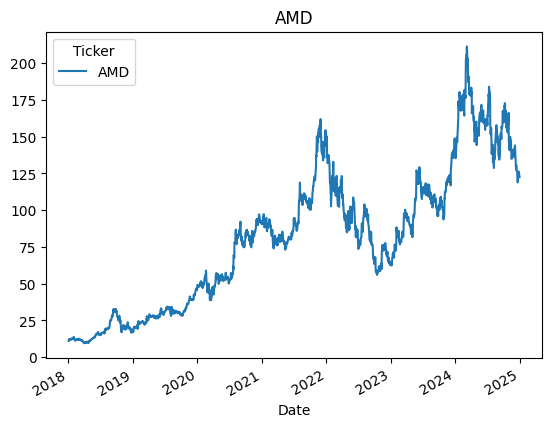

In [ ]:
stock.Close.plot()
plt.title(stock_ticket)
plt.show()

In [ ]:
stock_close = stock.Close

In [ ]:
stock_close.head()

Ticker,AMD
Date,
2018-01-02,10.98
2018-01-03,11.55
2018-01-04,12.12
2018-01-05,11.88
2018-01-08,12.28


Now, we will create the following classifications:

- 0: strong sell
- 1: sell
- 2: neutral
- 3: buy
- 4: strong buy

In [ ]:
# Stock classification pipeline
import numpy as np
import pandas as pd
import yfinance as yf

stock_ticket = "AMD"
stock = yf.download(stock_ticket, start="2018-01-01", end="2024-12-31", progress=False)

close = stock["Close"]
if isinstance(close, pd.DataFrame):
    close = close.iloc[:, 0]
close = close.dropna().astype(float)

eps = 0.0005

def to_series_1d(x):
    if isinstance(x, pd.DataFrame):
        x = x.iloc[:, 0]
    return x.astype(float)

def to_dir(r, eps=0.0):
    r = to_series_1d(r)
    d = np.zeros(r.shape[0], dtype=np.int8)
    d[r.values > eps] = 1
    d[r.values < -eps] = -1
    return pd.Series(d, index=r.index)

def fill_flat_with_prev_nonzero(dirs: pd.Series) -> pd.Series:
    out = dirs.fillna(0).copy().astype(np.int8)
    vals = out.values
    last = 0
    for i in range(len(vals)):
        if vals[i] == 0:
            vals[i] = last
        else:
            last = vals[i]
    out[:] = vals
    return out

#Capture all 9 transitions (Down/Neutral/Up -> Down/Neutral/Up) ---
def two_step_pattern(dirs: pd.Series) -> pd.Series:
    prev = dirs.shift(1)
    cur = dirs
    code = (prev + 1) * 3 + (cur + 1)
    code[(prev.isna()) | (cur.isna())] = np.nan
    return code

def label_from_next_return(r):
    if r < -0.05:
        return 0  # strong_sell
    if r < -0.01:
        return 1  # sell
    if r <= 0.01:
        return 2  # neutral
    if r <= 0.05:
        return 3  # buy
    return 4      # strong_buy

daily_dir = to_dir(close.pct_change(), eps=eps)
weekly_dir = to_dir(close.resample("W-FRI").last().pct_change(), eps=eps)
monthly_dir = to_dir(close.resample("ME").last().pct_change(), eps=eps)

weekly_dir_d = weekly_dir.reindex(close.index, method="ffill")
monthly_dir_d = monthly_dir.reindex(close.index, method="ffill")

daily_dir_f = fill_flat_with_prev_nonzero(daily_dir.reindex(close.index))
weekly_dir_f = fill_flat_with_prev_nonzero(weekly_dir_d)
monthly_dir_f = fill_flat_with_prev_nonzero(monthly_dir_d)

pat_d = two_step_pattern(daily_dir_f)
pat_w = two_step_pattern(weekly_dir_f)
pat_m = two_step_pattern(monthly_dir_f)
next_ret = close.pct_change().shift(-1)

data = pd.DataFrame(
    {
        "pat_daily": pat_d,
        "pat_weekly": pat_w,
        "pat_monthly": pat_m,
        "next_ret": next_ret,
    },
    index=close.index,
).dropna()

data["y"] = data["next_ret"].apply(label_from_next_return).astype(np.int32)

# Build sequence samples
daily_l, weekly_l, monthly_l = 15, 4, 6
max_l = max(daily_l, weekly_l, monthly_l)

x_day, x_week, x_month, y = [], [], [], []
for t in range(max_l - 1, len(data)):
    x_day.append(data["pat_daily"].iloc[t - daily_l + 1 : t + 1].values.astype(np.int32))
    x_week.append(data["pat_weekly"].iloc[t - weekly_l + 1 : t + 1].values.astype(np.int32))
    x_month.append(data["pat_monthly"].iloc[t - monthly_l + 1 : t + 1].values.astype(np.int32))
    y.append(int(data["y"].iloc[t]))

x_day = np.array(x_day, dtype=np.int32)
x_week = np.array(x_week, dtype=np.int32)
x_month = np.array(x_month, dtype=np.int32)
y = np.array(y, dtype=np.int32)

split = int(len(y) * 0.8)
x_train = {
    "input_day": x_day[:split],
    "input_week": x_week[:split],
    "input_month": x_month[:split],
}
x_test = {
    "input_day": x_day[split:],
    "input_week": x_week[split:],
    "input_month": x_month[split:],
}
y_train, y_test = y[:split], y[split:]

print("Data shape:", y.shape)
print("Train distribution:", np.unique(y_train, return_counts=True))

Data shape: (1744,)
Train distribution: (array([0, 1, 2, 3, 4], dtype=int32), array([ 82, 381, 411, 412, 109]))


/tmp/ipykernel_6971/2933494184.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download(stock_ticket, start="2018-01-01", end="2024-12-31", progress=False)


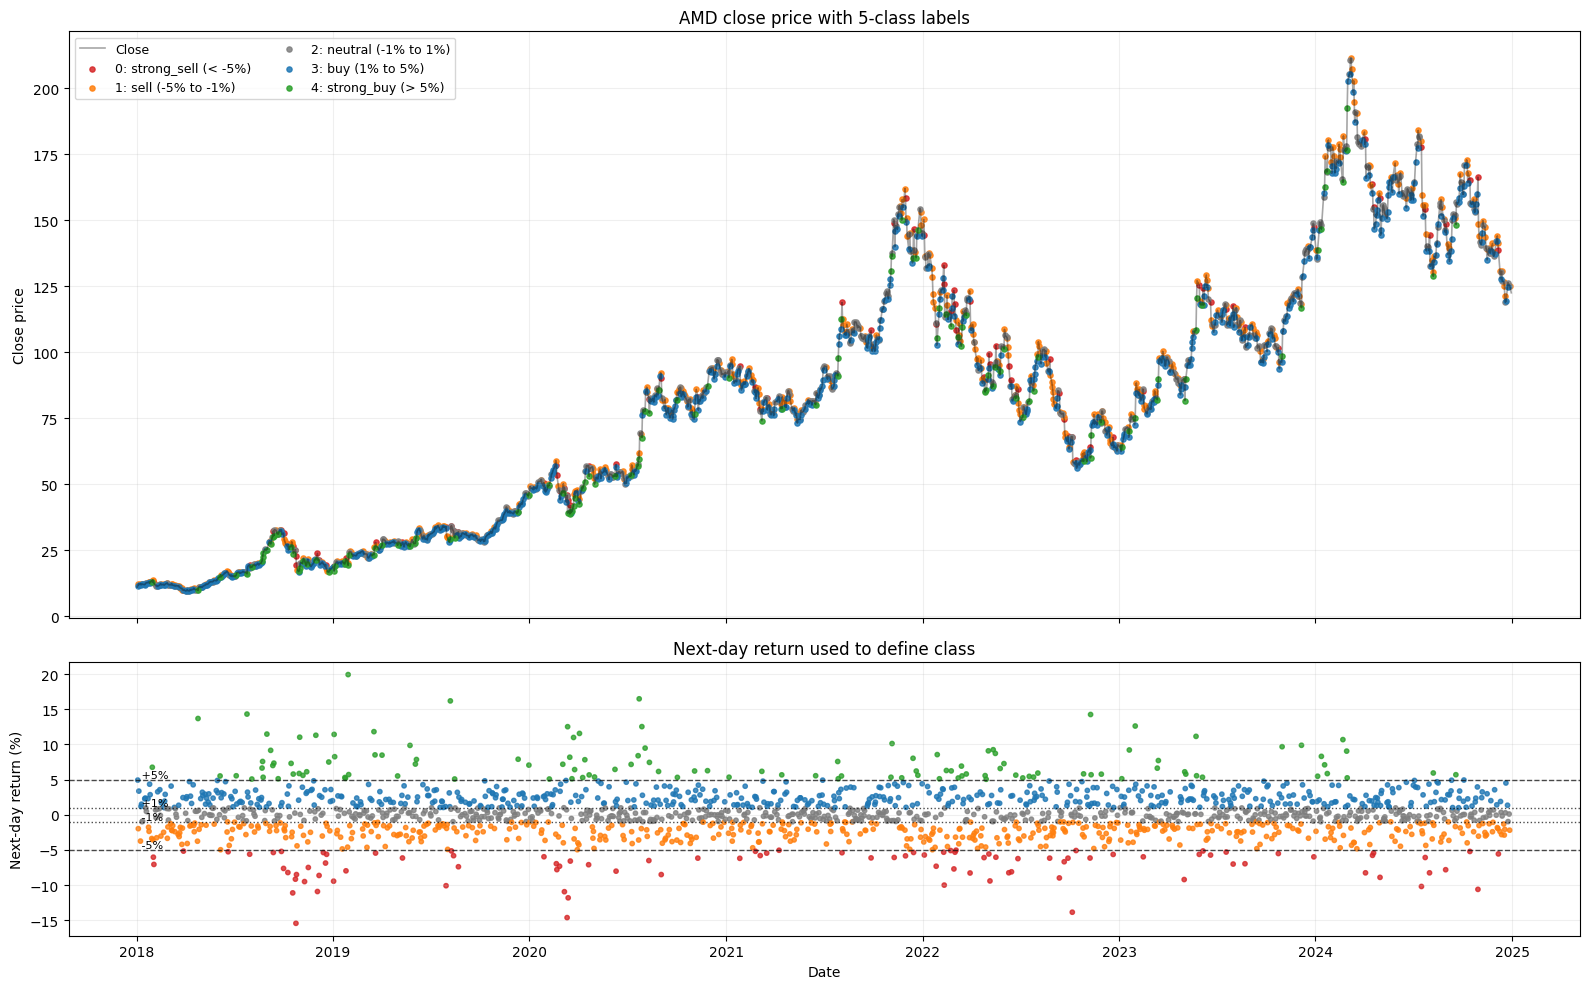

Class counts:
y
strong_sell (< -5%)     96
sell (-5% to -1%)      477
neutral (-1% to 1%)    539
buy (1% to 5%)         526
strong_buy (> 5%)      120
Name: count, dtype: int64


In [ ]:
# Visualize class assignment against stock price
import matplotlib.pyplot as plt

class_names = {
    0: "strong_sell (< -5%)",
    1: "sell (-5% to -1%)",
    2: "neutral (-1% to 1%)",
    3: "buy (1% to 5%)",
    4: "strong_buy (> 5%)",
}
class_colors = {
    0: "#d62728",  # red
    1: "#ff7f0e",  # orange
    2: "#7f7f7f",  # gray
    3: "#1f77b4",  # blue
    4: "#2ca02c",  # green
}

# Optional: set to an integer (e.g., 600) to plot only recent days
plot_last_n = None

plot_close = close.copy()
plot_data = data.copy()
if plot_last_n is not None:
    plot_close = close.iloc[-plot_last_n:]
    plot_data = data.loc[data.index.intersection(plot_close.index)]

fig, (ax_price, ax_ret) = plt.subplots(
    2,
    1,
    figsize=(16, 10),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1.4]},
)

# --- Top: close price with class-colored markers ---
ax_price.plot(plot_close.index, plot_close.values, color="black", alpha=0.35, lw=1.2, label="Close")
for cls in range(5):
    idx = plot_data.index[plot_data["y"] == cls]
    if len(idx) == 0:
        continue
    ax_price.scatter(
        idx,
        close.reindex(idx).values,
        s=14,
        color=class_colors[cls],
        alpha=0.85,
        label=f"{cls}: {class_names[cls]}",
    )

ax_price.set_title(f"{stock_ticket} close price with 5-class labels")
ax_price.set_ylabel("Close price")
ax_price.grid(alpha=0.2)
ax_price.legend(loc="upper left", ncol=2, fontsize=9)

# --- Bottom: next-day return with threshold lines ---
ret_pct = plot_data["next_ret"] * 100.0
ax_ret.scatter(
    plot_data.index,
    ret_pct,
    c=plot_data["y"].map(class_colors),
    s=10,
    alpha=0.8,
)

for yv, style, txt in [
    (-5, "--", "-5%"),
    (-1, ":", "-1%"),
    (1, ":", "+1%"),
    (5, "--", "+5%"),
]:
    ax_ret.axhline(y=yv, color="k", linestyle=style, linewidth=1, alpha=0.7)
    ax_ret.text(plot_data.index[0], yv, f" {txt}", va="bottom", fontsize=8)

ax_ret.set_title("Next-day return used to define class")
ax_ret.set_ylabel("Next-day return (%)")
ax_ret.set_xlabel("Date")
ax_ret.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print("Class counts:")
print(plot_data["y"].value_counts().sort_index().rename(index=class_names))

In [ ]:
# Define X, y, class weights
from tensorflow.keras.utils import to_categorical
from sklearn.utils import class_weight

# Recalculate everything to ensure consistency
daily_l, weekly_l, monthly_l = 15, 4, 6
max_l = max(daily_l, weekly_l, monthly_l)

x_day, x_week, x_month, y_raw = [], [], [], []

for t in range(max_l - 1, len(data)):
    x_day.append(data["pat_daily"].iloc[t - daily_l + 1 : t + 1].values.astype(np.int32))
    x_week.append(data["pat_weekly"].iloc[t - weekly_l + 1 : t + 1].values.astype(np.int32))
    x_month.append(data["pat_monthly"].iloc[t - monthly_l + 1 : t + 1].values.astype(np.int32))
    y_raw.append(int(data["y"].iloc[t]))

x_day = np.array(x_day, dtype=np.int32)
x_week = np.array(x_week, dtype=np.int32)
x_month = np.array(x_month, dtype=np.int32)
y_raw = np.array(y_raw, dtype=np.int32)

# --- Compute Class Weights ---
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_raw),
    y=y_raw
)
class_weights_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weights_dict)

# One-hot encode for training
y = to_categorical(y_raw, num_classes=5)

split = int(len(y) * 0.8)

x_train = {
    "input_day": x_day[:split],
    "input_week": x_week[:split],
    "input_month": x_month[:split],
}
x_test = {
    "input_day": x_day[split:],
    "input_week": x_week[split:],
    "input_month": x_month[split:],
}
y_train, y_test = y[:split], y[split:]

print("Train shapes:", x_train["input_day"].shape, y_train.shape)

Class Weights: {0: np.float64(3.6333333333333333), 1: np.float64(0.7358649789029535), 2: np.float64(0.65196261682243), 3: np.float64(0.6720616570327553), 4: np.float64(2.9066666666666667)}
Train shapes: (1395, 15) (1395, 5)


Now, you can create your network to try to predict wheather we should buy or sell stocks.  This model was not tested. It was given here for illustrational purposes. You should use it as a reference and create your own model.  For example, before flattening, you should probably use an `LSTM` or `GRU` model for the metrics to try to capture the temporal effect of the time series.

In [ ]:
def CreateModel(daily_l, weekly_l, monthly_l, o_shape):
    vocab_size = 9  # INCREASED from 6 to 9 (3 prev states * 3 cur states)
    embed_dim = 32
    rnn_units = 64
    bidirectional = True

    daily_i   = keras.layers.Input(shape=(daily_l,),   dtype='int32', name='input_day')
    weekly_i  = keras.layers.Input(shape=(weekly_l,),  dtype='int32', name='input_week')
    monthly_i = keras.layers.Input(shape=(monthly_l,), dtype='int32', name='input_month')

    emb = keras.layers.Embedding(input_dim=vocab_size, output_dim=embed_dim, name="state_embedding")

    daily_e   = emb(daily_i)
    weekly_e  = emb(weekly_i)
    monthly_e = emb(monthly_i)

    def rnn_block(x, name):
        rnn = keras.layers.LSTM(rnn_units, return_sequences=False, name=name)
        if bidirectional:
            rnn = keras.layers.Bidirectional(rnn, name=f"bi_{name}")
        return rnn(x)

    daily_h   = rnn_block(daily_e,   "lstm_day")
    weekly_h  = rnn_block(weekly_e,  "lstm_week")
    monthly_h = rnn_block(monthly_e, "lstm_month")

    x = keras.layers.Concatenate(name="concat_time_scales")([daily_h, weekly_h, monthly_h])

    x = keras.layers.Dense(128, activation='relu')(x)
    x = keras.layers.Dropout(0.3)(x)
    x = keras.layers.Dense(64, activation='relu')(x)
    x = keras.layers.Dropout(0.2)(x)

    out = keras.layers.Dense(o_shape, activation='softmax', name="class")(x)

    return keras.models.Model(inputs=(daily_i, weekly_i, monthly_i), outputs=out)

optimizer = keras.optimizers.Adam(learning_rate=1e-3)
model = CreateModel(daily_l=15, weekly_l=4, monthly_l=6, o_shape=5)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['acc'])
model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_day           │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_week          │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_month         │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ state_embedding     │ (None, 6, 32)     │        288 │ input_day[0][0],  │
│ (Embedding)         │                   │            │ input_week[0][0], │
│                     │                   │            │ input_month[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bi_lstm_day         │ (None, 128)       │     49,664 │ state_embedding[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bi_lstm_week        │ (None, 128)       │     49,664 │ state_embedding[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bi_lstm_month       │ (None, 128)       │     49,664 │ state_embedding[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_time_scales  │ (None, 384)       │          0 │ bi_lstm_day[0][0… │
│ (Concatenate)       │                   │            │ bi_lstm_week[0][… │
│                     │                   │            │ bi_lstm_month[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 128)       │     49,280 │ concat_time_scal… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 128)       │          0 │ dense_21[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 64)        │      8,256 │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 64)        │          0 │ dense_22[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class (Dense)       │ (None, 5)         │        325 │ dropout_15[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 207,141 (809.14 KB)

 Trainable params: 207,141 (809.14 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.utils import class_weight
import numpy as np

# Recalculate class weights locally to ensure they exist
y_train_int = np.argmax(y_train, axis=1)
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)
class_weights_dict = dict(enumerate(class_weights))
print("Using class weights:", class_weights_dict)

# Train the model
history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=64,
    verbose=True,
    validation_data=(x_test, y_test),
    class_weight=class_weights_dict
)

Using class weights: {0: np.float64(3.402439024390244), 1: np.float64(0.7322834645669292), 2: np.float64(0.6788321167883211), 3: np.float64(0.6771844660194175), 4: np.float64(2.5596330275229358)}
Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - acc: 0.9943 - loss: 0.0196 - val_acc: 0.2808 - val_loss: 7.3168
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.9931 - loss: 0.0150 - val_acc: 0.2779 - val_loss: 7.4376
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - acc: 0.9928 - loss: 0.0203 - val_acc: 0.2722 - val_loss: 7.4124
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.9894 - loss: 0.0349 - val_acc: 0.2607 - val_loss: 7.6957
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - acc: 0.9780 - loss: 0.0557 - val_acc: 0.2779 - val_loss: 7.1053
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - acc: 0.9792 - loss: 0.0465 - val_acc: 0.2722 - val_loss: 7.0931
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.9655 - loss: 0.0507 - val_acc: 0.2808 - va

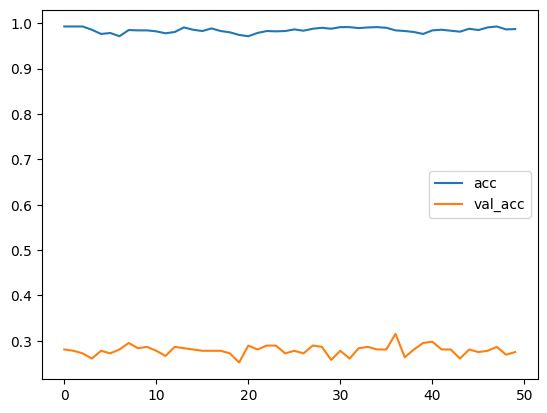

In [ ]:
plt.plot(history.history['acc'], label='acc')
plt.plot(history.history['val_acc'], label='val_acc')
plt.legend()
plt.show()

In [ ]:
model.evaluate(x_train, y_train), model.evaluate(x_test, y_test)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 1.0000 - loss: 6.6930e-04
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.2880 - loss: 7.3604


([0.0007061891374178231, 1.0], [7.523355484008789, 0.2750716209411621])

## Results
This is the random walk. Because stock price is affected by so many unknown variables ie. market volatility, consumer sentiment etc. The model cannot learn what the upcoming price will be solely based on prior trends.

# 3. IMDB Text Classification

In this next lab, you will create a text classification using LSTMs.

In [2]:
import tensorflow.keras
from keras import preprocessing
from keras.datasets import imdb
# Load imdb dataset and print a few samples to check.
#
# IMDB: sentence (x) -> positive/negative (y)
#
# “The food was really good”                             -> pos
# “The chicken crossed the road because it was uncooked” -> neg

num_words = 10000
maxlen = 100
embedded_size = 16

In [3]:
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=num_words)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
d = imdb.get_word_index()
for w in d:
    if d[w] == 22:
        print(w)
        break

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
you


In [5]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((25000,), (25000,), (25000,), (25000,))

In [ ]:
x_train[0]

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 2,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 2,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 2,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5,
 144,
 30,
 5535,
 18,

x_train has a size (training_size, ). Because the sentences have variable size, we cannot represent this in matrix format.

The first step is to make the column size constant. We do that by "padding" the sentences. If the sentences are bigger, we clip them. If they are smaller, we insert a "NO_WORD" token to the sentence.

In [6]:
import keras
x_train = keras.utils.pad_sequences(x_train, maxlen=maxlen)
x_test = keras.utils.pad_sequences(x_test, maxlen=maxlen)
x_train.shape, x_test.shape

((25000, 100), (25000, 100))

In [ ]:
x_train[0]

array([1415,   33,    6,   22,   12,  215,   28,   77,   52,    5,   14,
        407,   16,   82,    2,    8,    4,  107,  117, 5952,   15,  256,
          4,    2,    7, 3766,    5,  723,   36,   71,   43,  530,  476,
         26,  400,  317,   46,    7,    4,    2, 1029,   13,  104,   88,
          4,  381,   15,  297,   98,   32, 2071,   56,   26,  141,    6,
        194, 7486,   18,    4,  226,   22,   21,  134,  476,   26,  480,
          5,  144,   30, 5535,   18,   51,   36,   28,  224,   92,   25,
        104,    4,  226,   65,   16,   38, 1334,   88,   12,   16,  283,
          5,   16, 4472,  113,  103,   32,   15,   16, 5345,   19,  178,
         32], dtype=int32)

In [ ]:
def CreateModel(i_shape):
    x_i = keras.layers.Input(i_shape)
    x = keras.layers.Embedding(num_words, embedded_size,
                               input_length=maxlen)(x_i)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(1, activation="sigmoid")(x)

    return keras.models.Model(x_i, x)

model = CreateModel(x_train.shape[1:])
model.summary()

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["acc"])

D:\miniconda3\envs\torch-gpu\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ (None, 100, 16)             │         160,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │           1,601 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 161,601 (631.25 KB)

 Trainable params: 161,601 (631.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(
    x_train, y_train, epochs=20, batch_size=64,
    validation_split=0.2)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.6933 - loss: 0.6073 - val_acc: 0.7906 - val_loss: 0.4531
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.8661 - loss: 0.3366 - val_acc: 0.8498 - val_loss: 0.3432
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9099 - loss: 0.2400 - val_acc: 0.8546 - val_loss: 0.3284
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9435 - loss: 0.1760 - val_acc: 0.8496 - val_loss: 0.3361
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9686 - loss: 0.1239 - val_acc: 0.8470 - val_loss: 0.3525
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9854 - loss: 0.0827 - val_acc: 0.8470 - val_loss: 0.3718
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9941 - loss: 0.0548 - val_acc: 0.8450 - val_loss: 0.3846
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9981 - loss: 0.0359 - val_acc: 0.8426 - val_loss: 0.4062
Epoch 9/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - ac

In [ ]:
eval_result = model.evaluate(x_test, y_test)
eval_result[1]

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - acc: 0.8370 - loss: 0.5914


0.8370000123977661

- What's the current accuracy for this model? 83.7 %
- Try to add preloaded embeddings from GloVe from this model, see the
suggestion in https://blog.keras.io/using-pre-trained-word-embeddings-in-a-keras-model.html
- Question: why might this model help you get better accuracy? <br>There is understanding of a massive dataset of words relative to one another, so now there meaning can be extracted from a broader usage context rather than just the imdb data.
- Try using an LSTM instead of the models above.

In [1]:
from datasets import load_dataset
import numpy as np

EMBEDDING_DIM = 100

ds = load_dataset("SLU-CSCI4750/glove.6B.100d.txt", split="train")
embeddings_index = {}

for row in ds:
    line = row["text"] if isinstance(row, dict) else row
    values = line.split()
    if len(values) != EMBEDDING_DIM + 1:
        continue
    word = values[0]
    coefs = np.asarray(values[1:], dtype="float32")
    embeddings_index[word] = coefs

print("Found %s word vectors." % len(embeddings_index))

README.md:   0%|          | 0.00/30.0 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


glove.6B.100d.txt.gz:   0%|          | 0.00/134M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/400000 [00:00<?, ? examples/s]

Found 400000 word vectors.


In [7]:
import keras

word_index = imdb.get_word_index()
word_index = {word: (index + 3) for word, index in word_index.items()}
word_index["<PAD>"] = 0
word_index["<START>"] = 1
word_index["<UNK>"] = 2
word_index["<UNUSED>"] = 3

embedding_matrix = np.zeros((num_words, EMBEDDING_DIM), dtype="float32")
for word, i in word_index.items():
    if i >= num_words:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

# Same GloVe model, now using LSTM instead of Flatten
x_i = keras.layers.Input(shape=(maxlen,))
x = keras.layers.Embedding(
    input_dim=num_words,
    output_dim=EMBEDDING_DIM,
    weights=[embedding_matrix],
    trainable=False,
)(x_i)
x = keras.layers.LSTM(64)(x)
x = keras.layers.Dense(1, activation="sigmoid")(x)

glove_model = keras.models.Model(x_i, x)
glove_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["acc"])
glove_model.summary()

glove_model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
)

glove_eval = glove_model.evaluate(x_test, y_test)
print("GloVe LSTM model test accuracy:", glove_eval[1])

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,042,305 (3.98 MB)

 Trainable params: 42,305 (165.25 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - acc: 0.6620 - loss: 0.6025 - val_acc: 0.7684 - val_loss: 0.4793
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.7805 - loss: 0.4649 - val_acc: 0.7994 - val_loss: 0.4404
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.8049 - loss: 0.4240 - val_acc: 0.8004 - val_loss: 0.4281
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.8225 - loss: 0.3903 - val_acc: 0.8268 - val_loss: 0.3849
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.8382 - loss: 0.3672 - val_acc: 0.8218 - val_loss: 0.3875
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.8477 - loss: 0.3445 - val_acc: 0.8264 - val_loss: 0.3756
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.8542 - loss: 0.3315 - val_acc: 0.8370 - val_loss: 0.3622
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.8629 - loss: 0.3126 - val_acc: 0.8400 - val_loss: 0.3550
Epoch 9/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - ac

# 4. Generate Text from Nietzsche's Writings

In this example, you will generate text from Nietzsche's writings.

At least 20 epochs are required before the generated text
starts sounding coherent.

It is recommended to run this script on GPU, as recurrent
networks are quite computationally intensive.

If you try this script on new data, make sure your corpus
has at least ~100k characters. ~1M is better.

In [2]:
path = keras.utils.get_file("nietzsche.txt",
        origin="https://s3.amazonaws.com/text-datasets/nietzsche.txt")

text = open(path).read().lower()
print("corpus length:", len(text))

600901/600901 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
corpus length: 600893


In [3]:
print(text[:1000])

preface


supposing that truth is a woman--what then? is there not ground
for suspecting that all philosophers, in so far as they have been
dogmatists, have failed to understand women--that the terrible
seriousness and clumsy importunity with which they have usually paid
their addresses to truth, have been unskilled and unseemly methods for
winning a woman? certainly she has never allowed herself to be won; and
at present every kind of dogma stands with sad and discouraged mien--if,
indeed, it stands at all! for there are scoffers who maintain that it
has fallen, that all dogma lies on the ground--nay more, that it is at
its last gasp. but to speak seriously, there are good grounds for hoping
that all dogmatizing in philosophy, whatever solemn, whatever conclusive
and decided airs it has assumed, may have been only a noble puerilism
and tyronism; and probably the time is at hand when it will be once
and again understood what has actually sufficed for the basis of such
imposing and abso

In [4]:
chars = set(text)
print('total chars:', len(chars))
char_indices = dict((c, i) for i, c in enumerate(chars))
indices_char = dict((i, c) for i, c in enumerate(chars))

total chars: 57


In [5]:
# cut the text in semi-redundant sequences of maxlen characters
maxlen = 100
step = 3
sentences = []
next_chars = []
for i in range(0, len(text) - maxlen, step):
    sentences.append(text[i: i + maxlen])
    next_chars.append(text[i + maxlen])
print("nb sequences:", len(sentences))

nb sequences: 200265


In [6]:
print("Vectorization...")
X = np.zeros((len(sentences), maxlen, len(chars)), dtype=np.int8)
y = np.zeros((len(sentences), len(chars)), dtype=np.int8)
for i, sentence in enumerate(sentences):
    for t, char in enumerate(sentence):
        X[i, t, char_indices[char]] = 1
    y[i, char_indices[next_chars[i]]] = 1

Vectorization...


In [7]:
import keras
# build the model: 2 stacked LSTM
print("Build model...")
xi = keras.layers.Input((maxlen, len(chars)))
x = keras.layers.GRU(256, return_sequences=True)(xi)
x = keras.layers.Dropout(0.2)(x)
x = keras.layers.GRU(256, return_sequences=False)(x)
x = keras.layers.Dropout(0.2)(x)
x = keras.layers.Dense(len(chars))(x)
x = keras.layers.Activation("softmax")(x)

model = keras.models.Model(inputs=xi, outputs=x)
model.summary()

Build model...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 57)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 100, 256)       │       241,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 256)            │       394,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 57)             │        14,649 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 57)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 651,321 (2.48 MB)

 Trainable params: 651,321 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
adam = keras.optimizers.Adam(0.003)

model.compile(loss="categorical_crossentropy", optimizer=adam)

In [9]:
def sample(a, temperature=1.0):
    # helper function to sample an index from a probability array
    a = (np.log(a + 1e-8) / temperature).astype(np.float64)
    a = np.exp(a) / np.sum(np.exp(a))
    try:
      sample_result = np.argmax(np.random.multinomial(1, a, 1))
    except ValueError:
      error = 1.0 - np.sum(a)
      a[0] += error
      sample_result = np.argmax(np.random.multinomial(1, a, 1))
    return sample_result

In [10]:
import sys

# train the model, output generated text after each iteration
for iteration in range(1, 60):
    print()
    print("-" * 50)
    print("Iteration", iteration)

    model.fit(X, y, batch_size=4096, epochs=4)
    model.save_weights("model.weights.h5")

    start_index = random.randint(0, len(text) - maxlen - 1)

    for diversity in [0.2, 0.5, 1.0, 1.2]:
        print()
        print("----- diversity:", diversity)

        generated = ""
        sentence = text[start_index: start_index + maxlen]
        generated += sentence
        print("----- Generating with seed: '" + sentence + "'")
        sys.stdout.write(generated)

        for i in range(200):
            x = np.zeros((1, maxlen, len(chars)))
            for t, char in enumerate(sentence):
                x[0, t, char_indices[char]] = 1.

            # predict next char
            preds = model.predict(x, verbose=0)[0]
            next_index = sample(preds, diversity)
            next_char = indices_char[next_index]

            # full sentence being generated
            generated += next_char

            # shift sentence
            sentence = sentence[1:] + next_char

            sys.stdout.write(next_char)
            sys.stdout.flush()

            # let's consider only one sentence
            if next_char == ".":
              break
        print()


--------------------------------------------------
Iteration 1
Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - loss: 3.1909
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 2.3392
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 2.1061
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 1.9452

----- diversity: 0.2
----- Generating with seed: 'conduct, and it
is manifest that it was the consideration of universal utility that
prompted praise '
conduct, and it
is manifest that it was the consideration of universal utility that
prompted praise of the supper the man it is a the seally the soure and as a the senting the sould the sould and the sertare of the sould and the supper and the senter of the sention of the self the self and the sente

----- diversity: 0.5
----- Generating with seed: 'conduct, and it
is manifest that it was the consideration of universal utility that
prompted praise '
conduct, and it
is manifest that it was the consideration of universa

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_529/1144755224.py", line 30, in <cell line: 0>
    preds = model.predict(x, verbose=0)[0]
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/keras/src/utils/traceback_utils.py", line 117, in error_handler
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py", line 566, in predict
    batch_outputs = self.predict_function(data)
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/util/traceback_utils.py", line 150, in error_handler
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/eager/polymorphic_functi

TypeError: object of type 'NoneType' has no len()

### Results

We see the model go from producing random characters that sound like gibberish, to real English language, which even begins to make some sense in a few cases.

- Pick up one set of data samples from linux kernel source code (https://github.com/torvalds/linux)
- Modify the model to be trained in the corpus
- Present the results

In [11]:
import requests

# Download a few key Linux kernel source files to build a corpus
urls = [
    "https://raw.githubusercontent.com/torvalds/linux/master/kernel/sched/core.c",
    "https://raw.githubusercontent.com/torvalds/linux/master/mm/memory.c",
    "https://raw.githubusercontent.com/torvalds/linux/master/kernel/fork.c"
]

linux_text = ""
for url in urls:
    response = requests.get(url)
    if response.status_code == 200:
        linux_text += response.text

linux_text = linux_text.lower()
print("Corpus length:", len(linux_text))

Corpus length: 590151


In [12]:
import numpy as np
import random
import sys
import keras

# Create character mappings
chars = sorted(list(set(linux_text)))
print('total chars:', len(chars))
char_indices = dict((c, i) for i, c in enumerate(chars))
indices_char = dict((i, c) for i, c in enumerate(chars))

# Cut the text in semi-redundant sequences of maxlen characters
maxlen = 100
step = 3
sentences = []
next_chars = []
for i in range(0, len(linux_text) - maxlen, step):
    sentences.append(linux_text[i: i + maxlen])
    next_chars.append(linux_text[i + maxlen])
print("nb sequences:", len(sentences))

print("Vectorization...")
x_linux = np.zeros((len(sentences), maxlen, len(chars)), dtype=np.bool_)
y_linux = np.zeros((len(sentences), len(chars)), dtype=np.bool_)
for i, sentence in enumerate(sentences):
    for t, char in enumerate(sentence):
        x_linux[i, t, char_indices[char]] = 1
    y_linux[i, char_indices[next_chars[i]]] = 1

total chars: 70
nb sequences: 196684
Vectorization...


In [13]:
# Build the model (Same architecture as before)
print("Build model...")
input_layer = keras.layers.Input((maxlen, len(chars)))
x = keras.layers.GRU(256, return_sequences=True)(input_layer)
x = keras.layers.Dropout(0.2)(x)
x = keras.layers.GRU(256, return_sequences=False)(x)
x = keras.layers.Dropout(0.2)(x)
output_layer = keras.layers.Dense(len(chars), activation="softmax")(x)

linux_model = keras.models.Model(inputs=input_layer, outputs=output_layer)
linux_model.compile(loss="categorical_crossentropy", optimizer="adam")

Build model...


In [15]:
# Helper function to sample an index from a probability array
def sample(preds, temperature=1.0):
    preds = np.asarray(preds).astype('float64')
    preds = np.log(preds + 1e-8) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    probas = np.random.multinomial(1, preds, 1)
    return np.argmax(probas)

# Train the model, output generated text after each iteration
for iteration in range(1, 10):  # Run for fewer iterations to save time
    print()
    print("-" * 50)
    print("Iteration", iteration)

    linux_model.fit(x_linux, y_linux, batch_size=2048, epochs=4)

    start_index = random.randint(0, len(linux_text) - maxlen - 1)

    for diversity in [0.2, 0.5, 1.0, 1.2]:
        print()
        print("----- diversity:", diversity)

        generated = ""
        sentence = linux_text[start_index: start_index + maxlen]
        generated += sentence
        print("----- Generating with seed: '" + sentence + "'")
        sys.stdout.write(generated)

        for i in range(200):
            x_pred = np.zeros((1, maxlen, len(chars)))
            for t, char in enumerate(sentence):
                x_pred[0, t, char_indices[char]] = 1.

            preds = linux_model.predict(x_pred, verbose=0)[0]
            next_index = sample(preds, diversity)
            next_char = indices_char[next_index]

            generated += next_char
            sentence = sentence[1:] + next_char

            sys.stdout.write(next_char)
            sys.stdout.flush()
        print()


--------------------------------------------------
Iteration 1
Epoch 1/4
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 2.6136
Epoch 2/4
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 2.2862
Epoch 3/4
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 2.0860
Epoch 4/4
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 1.9263

----- diversity: 0.2
----- Generating with seed: 'if (mask & arch_page_table_sync_mask)
		arch_sync_kernel_mappings(start, start + size);

	return err'
if (mask & arch_page_table_sync_mask)
		arch_sync_kernel_mappings(start, start + size);

	return err;
		pree_pte_struct *p);

	if (pte_struct *p)
{
	if (!preempt_denabled))
			return 0;

	if (!pte_mask_struct *p)
{
	if (!preempt_struct *pre, pte))
		return 0;

	if (pte_struct *pud)
																	

----- diversity: 0.5
----- Generating with seed: 'if (mask & arch_page_table_sync_mask)
		arch_sync_kernel_mappings(start, start + size);

	return err'
if (mask & arch_page_table_sync_mask)
		arch_sync_kernel_mappings(sta

### Results

We can really see how training on different data impacts results. From the beginning the language created is taking the form of a programming language with lots of whitespace, parantheses, and indentations. It begins with meaningless if statements and starts to identify real patterns like structuring conditions, pointer references, and variable types. While I am not very familiar with Nietzsche's writings, as a student of programming, it is easy to recognize how these outputs resemble C.